# GOES CONUS and mesoscale imagery

The Advanced Baseline Imager (ABI) on NOAA's GOES-R series satellites scans
the Americas in sixteen channels. NOAA publishes its Level 2 Cloud and
Moisture Imagery (CMIP) to public S3 buckets, one per satellite, as
NetCDF4 files: one file is one channel of one scan of one sector, with no
geographic or variable subsetting.

This walkthrough pulls one channel-13 (10.3 µm infrared) CONUS scene from
GOES-18 at 12:01 UTC on 6 May 2024, keeps the pixels the source flags as good,
and turns the file's scan angles into latitude and longitude. It needs
`usdata[netcdf]` and matplotlib, downloads about 3.8 MB, and runs in a few
seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; NumPy {np.__version__}")

Executed (UTC): 2026-09-24T05:56:46+00:00
usdata 0.26.0; xarray 2026.7.0; NumPy 2.5.2


## Select

The manifest names a satellite (18), a channel (13), and the product
`ABI-L2-CMIPC`, the CONUS sector; there is no default satellite or channel.
The window selects scans by their start time, inclusive at both ends, and a
scan that started before the window is not selected even if it was still
running. Both bounds here equal one scan's start, to the tenth of a second,
so the query selects exactly that scene. Channel 13 is infrared, so the scene
is the same by day and night.

In [2]:
print(manifest.read_text())

name: goes18-infrared-scene
sources:
  - dataset: noaa:goes-abi
    start: 2024-05-06T12:01:18.1Z
    end: 2024-05-06T12:01:18.1Z
    params:
      satellite: 18
      channel: 13
      product: ABI-L2-CMIPC



## What arrives

One NetCDF4 file, named for the product, channel, satellite, and the scan's
start, end, and creation times. The committed `dataset.lock.json` pins its S3
URL and checksum, so a pull restores exactly these bytes.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)
print("Scan:", item.asset.time.start.isoformat(), "to", item.asset.time.end.isoformat())

File: OR_ABI-L2-CMIPC-M6C13_G18_s20241271201181_e20241271203566_c20241271204061.nc
Bytes: 3821830
Source: s3://noaa-goes18/ABI-L2-CMIPC/2024/127/12/OR_ABI-L2-CMIPC-M6C13_G18_s20241271201181_e20241271203566_c20241271204061.nc
Retrieved (UTC): 2026-09-24T05:56:47+00:00
Checksum: sha256:3331dc3dcf67f3015e221484750fefebead4c51d728272045c3e31c9123a0c0a
Scan: 2024-05-06T12:01:18.100000+00:00 to 2024-05-06T12:03:56.600000+00:00


## Open

The NetCDF reader returns an xarray Dataset with scale, offset, and fill
values decoded and the file closed. `CMI` is brightness temperature in kelvin
for an infrared channel (reflectance for a visible one), and `DQF` is the
per-pixel quality flag; masking on it is the analysis's choice, made here by
keeping `DQF == 0`. Place is the geostationary fixed grid: `x` and `y` are
scan angles in radians from the satellite, described by
`goes_imager_projection`. Time is the scan's midpoint `t`, with the start and
end in the file's attributes.

In [4]:
scene = item.open()
cmi = scene["CMI"]
brightness = cmi.where(scene["DQF"] == 0)
projection = scene["goes_imager_projection"].attrs
print("Grid:", dict(cmi.sizes), "in", scene["x"].attrs["units"])
print("CMI:", cmi.attrs["long_name"], f"({cmi.attrs['units']})")
print("Quality flags:", scene["DQF"].attrs["flag_meanings"])
print("Good pixels:", int(brightness.count()), "of", brightness.size)
origin = projection["longitude_of_projection_origin"]
print("Projection:", projection["grid_mapping_name"], f"centred on {origin} °E")
print("Scan:", scene.attrs["time_coverage_start"], "to", scene.attrs["time_coverage_end"])
print(f"Brightness temperature: {float(brightness.min()):.1f} to {float(brightness.max()):.1f} K")

Grid: {'y': 1500, 'x': 2500} in rad
CMI: ABI L2+ Cloud and Moisture Imagery brightness temperature (K)
Quality flags: good_pixel_qf conditionally_usable_pixel_qf out_of_range_pixel_qf no_value_pixel_qf focal_plane_temperature_threshold_exceeded_qf
Good pixels: 3750000 of 3750000
Projection: geostationary centred on -137.0 °E
Scan: 2024-05-06T12:01:18.1Z to 2024-05-06T12:03:56.6Z
Brightness temperature: 208.3 to 296.3 K


The reader does not reproject. The GOES-R Product User's Guide gives the
conversion from scan angle to geodetic latitude and longitude, using only the
projection attributes in the file. Longitude is left continuous, so points
west of the dateline are below −180.

In [5]:
r_eq = projection["semi_major_axis"]
r_pol = projection["semi_minor_axis"]
height = projection["perspective_point_height"] + r_eq
x, y = np.meshgrid(scene["x"].values.astype(float), scene["y"].values.astype(float))
a = np.sin(x) ** 2 + np.cos(x) ** 2 * (np.cos(y) ** 2 + (r_eq / r_pol) ** 2 * np.sin(y) ** 2)
b = -2 * height * np.cos(x) * np.cos(y)
c = height**2 - r_eq**2
distance = (-b - np.sqrt(b**2 - 4 * a * c)) / (2 * a)
sx = distance * np.cos(x) * np.cos(y)
sy = -distance * np.sin(x)
sz = distance * np.cos(x) * np.sin(y)
lat = np.degrees(np.arctan((r_eq / r_pol) ** 2 * sz / np.sqrt((height - sx) ** 2 + sy**2)))
lon = projection["longitude_of_projection_origin"] - np.degrees(np.arctan(sy / (height - sx)))
extent = scene["geospatial_lat_lon_extent"].attrs
print(f"Computed: {lat.min():.2f} to {lat.max():.2f} °N, {lon.min():.2f} to {lon.max():.2f} °E")
print(
    f"File says: {extent['geospatial_southbound_latitude']:.2f} to "
    f"{extent['geospatial_northbound_latitude']:.2f} °N, "
    f"{extent['geospatial_westbound_longitude']:.2f} to "
    f"{extent['geospatial_eastbound_longitude']:.2f} °E"
)

Computed: 14.57 to 53.50 °N, -184.38 to -89.62 °E
File says: 14.57 to 53.50 °N, 175.62 to -89.62 °E


## A first look

The scene on latitude and longitude, cold cloud tops white, with the 235 K
contour, a threshold often used for deep convective cloud, in orange. The
plot draws every fourth pixel; the numbers below use every good pixel.

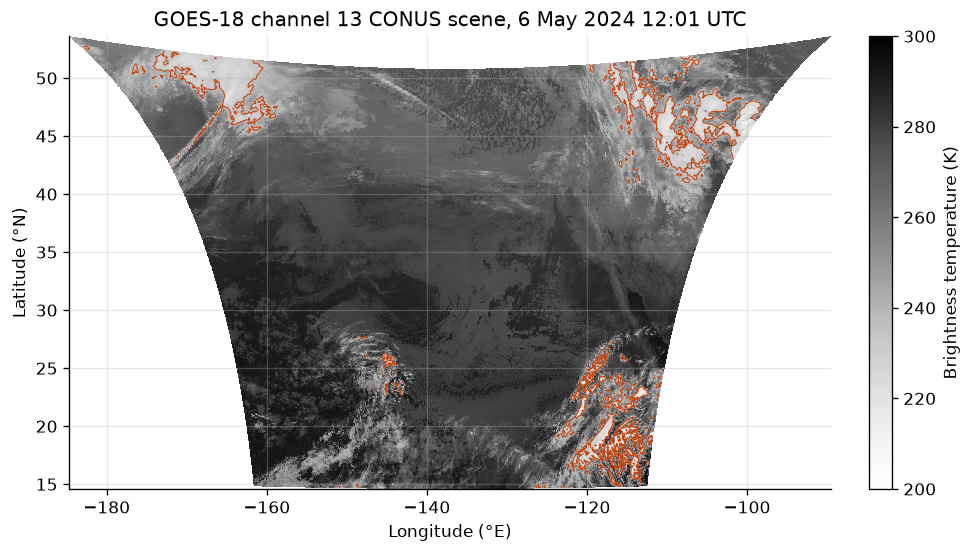

In [6]:
every = slice(None, None, 4)
fig, ax = plt.subplots(layout="constrained")
mesh = ax.pcolormesh(
    lon[every, every],
    lat[every, every],
    brightness.values[every, every],
    cmap="Greys",
    vmin=200,
    vmax=300,
    shading="auto",
    rasterized=True,
)
ax.contour(
    lon[every, every],
    lat[every, every],
    brightness.values[every, every],
    levels=[235],
    colors="#c2410c",
    linewidths=0.6,
)
fig.colorbar(mesh, ax=ax, label="Brightness temperature (K)")
start = item.asset.time.start
ax.set(
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    title=f"GOES-18 channel 13 CONUS scene, {start.day} {start:%B %Y %H:%M} UTC",
)
plt.show()

In [7]:
values = brightness.values
cold = values < 235
coldest = np.nanargmin(values)
print(f"Pixels colder than 235 K: {cold.mean():.1%} of the scene")
print(
    f"Coldest pixel: {values.flat[coldest]:.1f} K at "
    f"{lat.flat[coldest]:.1f} °N, {lon.flat[coldest]:.1f} °E"
)
print(f"Warmest pixel: {np.nanmax(values):.1f} K")

Pixels colder than 235 K: 3.9% of the scene
Coldest pixel: 208.3 K at 19.4 °N, -111.6 °E
Warmest pixel: 296.3 K


GOES-18 is GOES-West, and its "CONUS" sector is centred on 137°W: it covers
the eastern Pacific and the western United States, and its eastern edge is
near 90°W. Most of the scene is warm: clear sky or low cloud. The cold, high
cloud sits in three corners: over the northern Rockies and southern Canada,
south of the Aleutians, and over the Pacific off western Mexico, which holds
the coldest pixel.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:goes-abi
  NOAA Geostationary Operational Environmental Satellites (GOES) 16, 17, 18 & 19 was accessed on 2026-09-16 from https://registry.opendata.aws/noaa-goes
  homepage: https://registry.opendata.aws/noaa-goes/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-16; 1 checksummed asset (3,821,830 bytes) pinned by usdata 0.18.0
  sources: 1


## What was awkward

- Selecting one scene means knowing its start to the tenth of a second
  (`12:01:18.1Z`), which comes from listing the archive first; a window of a
  few minutes returns every scan that started in it instead.
- "CONUS" depends on the satellite. GOES-18's sector is the Pacific-centred
  West view, which misses the central and eastern states; for Oklahoma or
  anything east of about 90°W, ask for GOES-16 or GOES-19.
- The file places pixels by scan angle, and the reader does not reproject.
  Latitude and longitude take the dozen lines above, and a map with
  coastlines or state lines needs a mapping library that is not an extra.
- The sector runs past the dateline, so longitude is either continuous below
  −180 or wraps to +175; code that assumes −180 to 180 splits the scene.
- Quality masking is the analysis's job. In this scene every pixel is flagged
  good, which will not be true of every scene or channel.
- Channel 13 brightness temperature is the temperature of whatever the sensor
  sees, cloud top or ground, not surface air temperature.

See the [GOES ABI guide](https://docs.usdata.dev/providers/noaa-goes/) for
satellites, sectors, and window limits, and the
[mesoscale study](https://usdata.dev/studies/goes-mesoscale/) for a sequence of
one-minute scenes.